## Importing the necessary libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

#### Data Ingestion

In [5]:
df = pd.read_csv('household_power_consumption.csv')

In [6]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


### Basic Data Understanding 

1. What is the total number of records in the dataset? 

In [7]:
df.shape

(1048575, 9)

* This data has 1048575 rows and 9 columns

2. Are there any missing values in the dataset? If so, in which columns?

In [8]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

* There are 4069 missing values in the column named Sub_metering_3

3. What are the data types of each column? 

In [9]:
df.dtypes

Date                         str
Time                         str
Global_active_power          str
Global_reactive_power        str
Voltage                      str
Global_intensity             str
Sub_metering_1               str
Sub_metering_2               str
Sub_metering_3           float64
dtype: object

4. What is the range of dates present in the dataset? 

Hence our dataset refers Date column as object data type, so converting it into datetime: 

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
print(df["Date"].dtypes)

datetime64[us]


In [12]:
print(df["Date"].min(), "to", df["Date"].max())

2006-12-16 00:00:00 to 2008-12-13 00:00:00


### Descriptive Statistics

In [13]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,2006-12-16,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


5. First you have to make a Total_Submetering column by adding the all submeterings. 

In our dataset the Sub_metering_3 column is of float type and columns Sub_metering_2 and Sub_metering_1 are object/str type, first we have to convert all three columns into numeric.

In [14]:
df["Sub_metering_1"] = pd.to_numeric(df["Sub_metering_1"], errors="coerce")
df["Sub_metering_2"] = pd.to_numeric(df["Sub_metering_2"], errors="coerce")
df["Sub_metering_3"] = pd.to_numeric(df["Sub_metering_3"], errors="coerce")

In [15]:
df["Total_Submetering"] = (
    df["Sub_metering_1"] +
    df["Sub_metering_2"] +
    df["Sub_metering_3"]
)

In [16]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Submetering
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,18.0
1,2006-12-16,17:25:00,5.36,0.436,233.63,23,0.0,1.0,16.0,17.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23,0.0,2.0,17.0,19.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23,0.0,1.0,17.0,18.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,18.0


6. What are the summary statistics (mean, median, min, max, standard deviation) for 
global_active_power, global_reactive_power, voltage, and global_intensity? 

In [17]:
df[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]].describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
count,1048575,1048575,1048575,1048575
unique,4076,492,2605,219
top,0.218,0,?,1
freq,6714,266300,4069,95350


above columns are str type so we are not able to calculate statistical info of these columns, so first we have to convert them into numeric

In [18]:
df[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]] = (
    df[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]]
    .apply(pd.to_numeric, errors="coerce")
)

In [19]:
df[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]].describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01


7. What is the mean and standard deviation of the Total_Submetering column? 

In [20]:
df['Total_Submetering'].describe()

count    1.044506e+06
mean     8.586465e+00
std      1.325575e+01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.800000e+01
max      1.290000e+02
Name: Total_Submetering, dtype: float64

8. What is the distribution of voltage in the dataset? (e.g., histogram or KDE plot) 

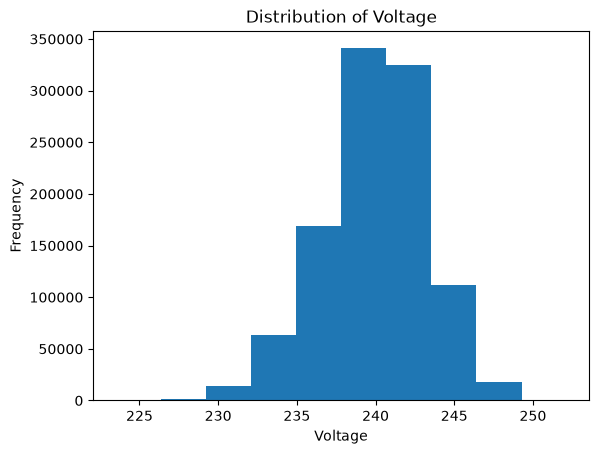

In [21]:
plt.hist(df["Voltage"])

plt.xlabel("Voltage")
plt.ylabel("Frequency")
plt.title("Distribution of Voltage")
plt.show()

9. What is the correlation between global_active_power and global_intensity? 

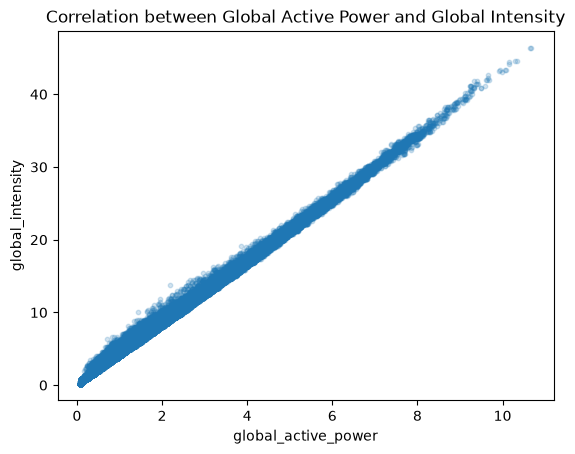

In [22]:
y = df["Global_intensity"]
x = df["Global_active_power"]

plt.scatter(x, y, alpha = 0.2, s = 10)

plt.xlabel("global_active_power")
plt.ylabel("global_intensity")
plt.title("Correlation between Global Active Power and Global Intensity")
plt.show()

10. How does global_active_power vary with voltage? 

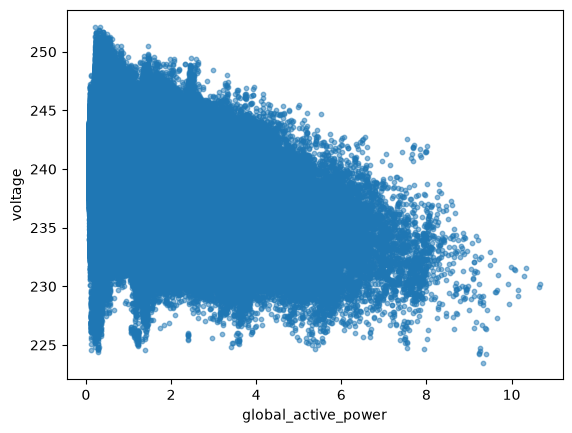

In [24]:
y = df["Voltage"]
x = df["Global_active_power"]

plt.scatter(x, y, alpha = 0.5, s = 10)

plt.xlabel("global_active_power")
plt.ylabel("voltage")
plt.show()

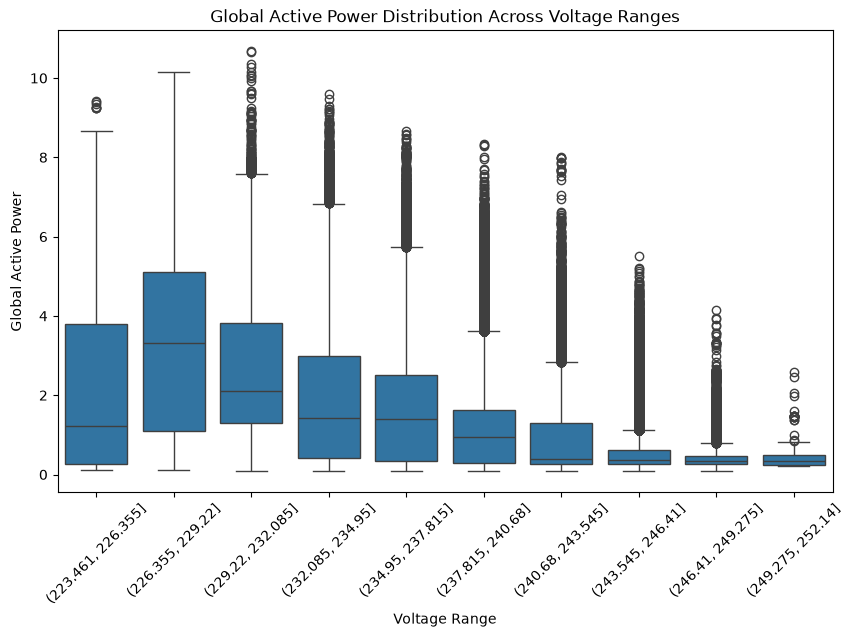

In [25]:
# Create voltage bins
df["Voltage_bin"] = pd.cut(df["Voltage"], bins=10)

# Box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Voltage_bin",
    y="Global_active_power",
    data=df
)

plt.xlabel("Voltage Range")
plt.ylabel("Global Active Power")
plt.title("Global Active Power Distribution Across Voltage Ranges")
plt.xticks(rotation=45)
plt.show()

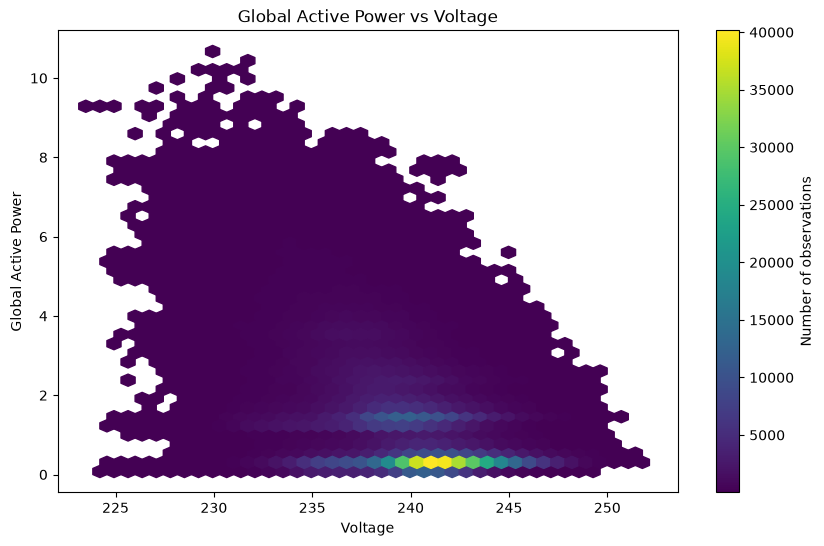

In [26]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    df["Voltage"],
    df["Global_active_power"],
    gridsize=40,
    mincnt=1
)

plt.xlabel("Voltage")
plt.ylabel("Global Active Power")
plt.title("Global Active Power vs Voltage")

plt.colorbar(label="Number of observations")

plt.show()

11. What are the minimum and maximum values of global_active_power, and at what 
times did they occur?

In [27]:
# Minimum
min_idx = df["Global_active_power"].idxmin()

print("Minimum Global Active Power:")
print(df.loc[min_idx, ["Date", "Time", "Global_active_power"]])

# Maximum
max_idx = df["Global_active_power"].idxmax()

print("\nMaximum Global Active Power:")
print(df.loc[max_idx, ["Date", "Time", "Global_active_power"]])

Minimum Global Active Power:
Date                   2008-08-12 00:00:00
Time                              19:26:00
Global_active_power                  0.076
Name: 871322, dtype: object

Maximum Global Active Power:
Date                   2007-03-04 00:00:00
Time                              19:34:00
Global_active_power                  10.67
Name: 112450, dtype: object


# Time-Based Analysis

11. How does global_active_power change over different hours of the day? (Hourly trend)

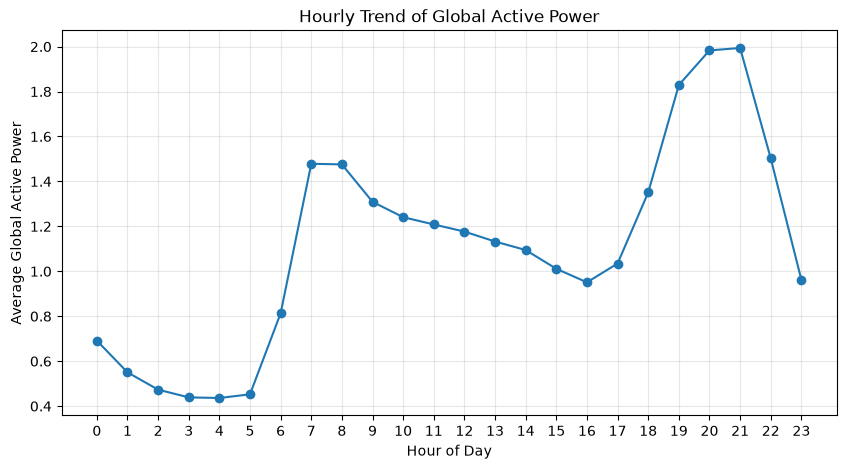

In [28]:
# Extract hour from Time
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

# Calculate average power for each hour
hourly_power = df.groupby("Hour")["Global_active_power"].mean()

# Plot hourly trend
plt.figure(figsize=(10, 5))

plt.plot(hourly_power.index, hourly_power.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.title("Hourly Trend of Global Active Power")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

12. Are there any noticeable trends in power consumption over different days of the week? 

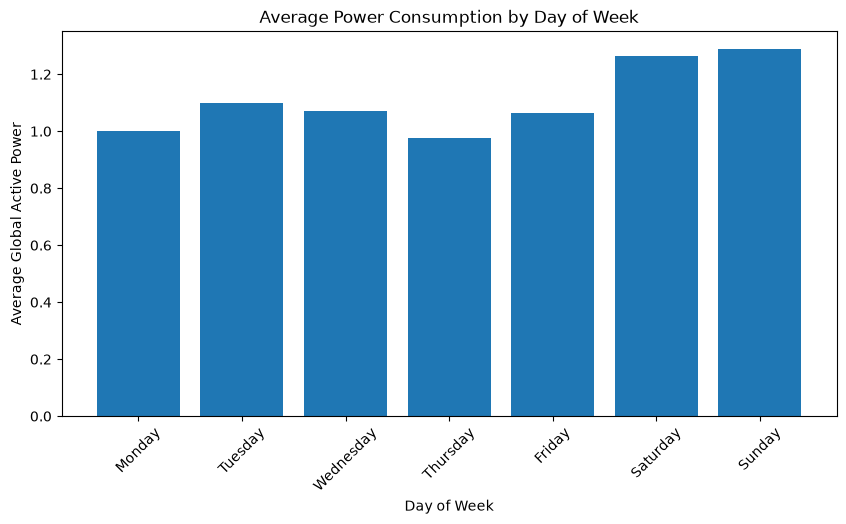

In [29]:
# Convert Date to datetime if not already done
df["Date"] = pd.to_datetime(df["Date"])

# Extract day of week
df["Day"] = df["Date"].dt.day_name()

# Calculate average power consumption by day
daily_power = df.groupby("Day")["Global_active_power"].mean()

# Arrange days in correct order
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_power = daily_power.reindex(days_order)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(daily_power.index, daily_power.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Consumption by Day of Week")
plt.xticks(rotation=45)

plt.show()

13. How does Total_Submetering change over different hours of the day? 

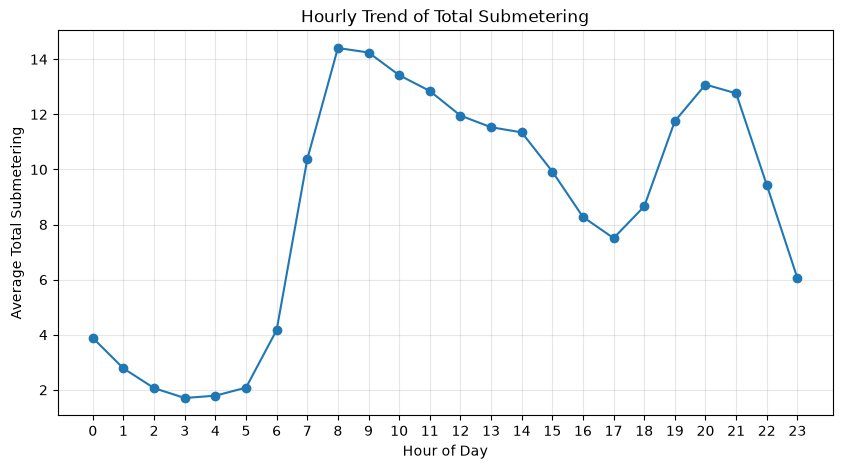

In [30]:
# Extract hour from Time
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

# Average Total_Submetering by hour
hourly_submetering = df.groupby("Hour")["Total_Submetering"].mean()

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_submetering.index,
    hourly_submetering.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Total Submetering")
plt.title("Hourly Trend of Total Submetering")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

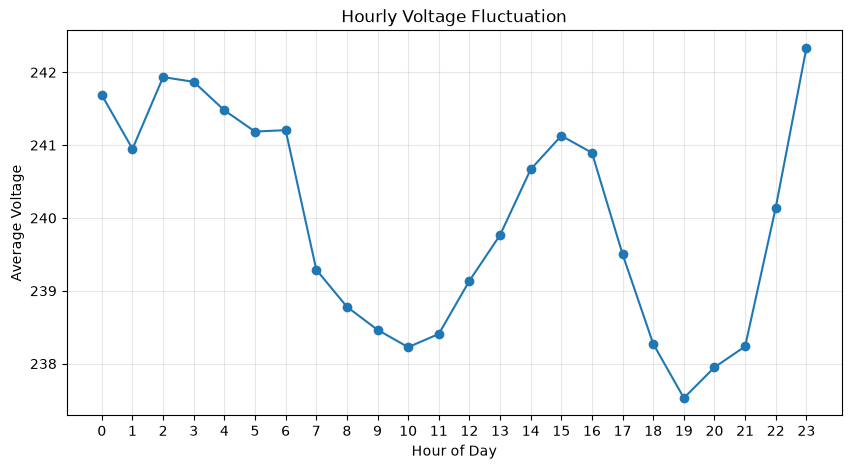

In [31]:
# Extract hour from Time
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

# Average voltage for each hour
hourly_voltage = df.groupby("Hour")["Voltage"].mean()

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_voltage.index,
    hourly_voltage.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Voltage")
plt.title("Hourly Voltage Fluctuation")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.show()

15. What is the average global_active_power usage for each month?

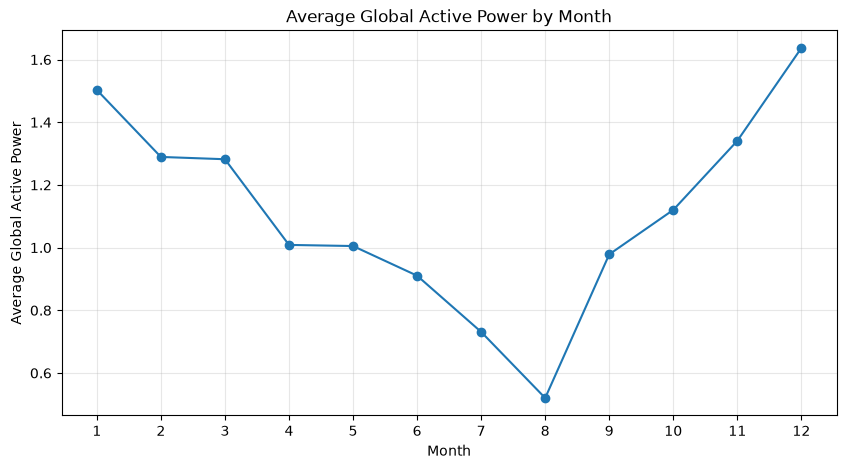

In [32]:
# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract month
df["Month"] = df["Date"].dt.month

# Calculate monthly average
monthly_power = df.groupby("Month")["Global_active_power"].mean()

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_power.index,
    monthly_power.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.title("Average Global Active Power by Month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.show()

# Sub-Metering Analysis 

In [33]:
submetering_avg = df[
    ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
].mean()

print(submetering_avg)

Sub_metering_1    1.177451
Sub_metering_2    1.475177
Sub_metering_3    5.933837
dtype: float64


In [34]:
print(submetering_avg.idxmax())
print(submetering_avg.max())

Sub_metering_3
5.933836665370999


In [35]:
print(
    "Highest average consumption:",
    submetering_avg.idxmax(),
    "=",
    submetering_avg.max()
)

Highest average consumption: Sub_metering_3 = 5.933836665370999


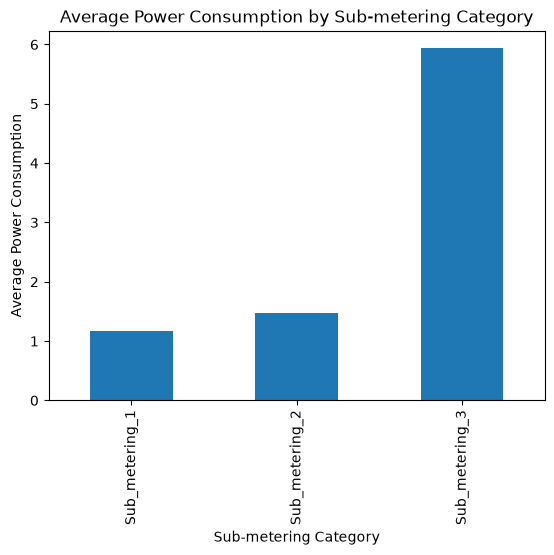

In [36]:
submetering_avg.plot(kind="bar")

plt.xlabel("Sub-metering Category")
plt.ylabel("Average Power Consumption")
plt.title("Average Power Consumption by Sub-metering Category")
plt.show()

17. How does Total_Submetering compare with global_active_power? Is there a strong 
correlation? 

Correlation: 0.8315145305268761


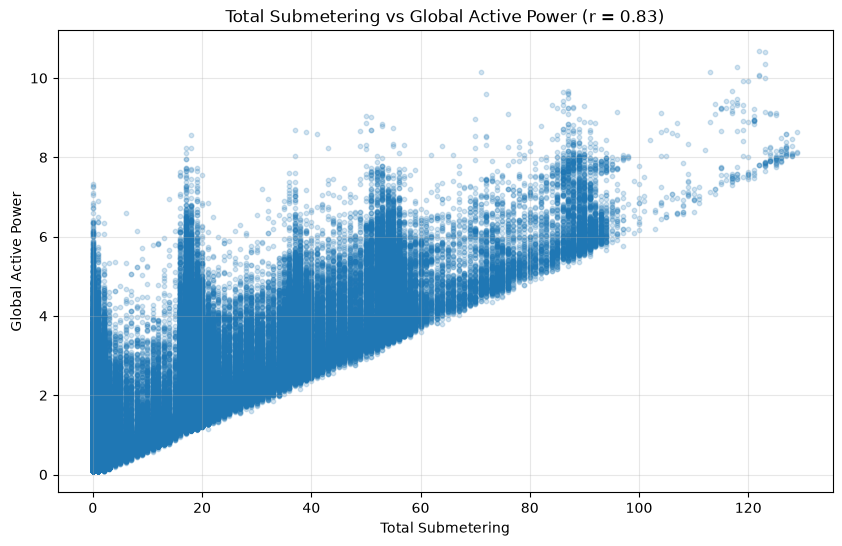

In [37]:
# Calculate correlation
correlation = df["Total_Submetering"].corr(df["Global_active_power"])

print("Correlation:", correlation)

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Total_Submetering"],
    df["Global_active_power"],
    alpha=0.2,
    s=10
)

plt.xlabel("Total Submetering")
plt.ylabel("Global Active Power")
plt.title(f"Total Submetering vs Global Active Power (r = {correlation:.2f})")
plt.grid(alpha=0.3)

plt.show()

18. How much energy is consumed outside of the three sub-metering categories 
(global_active_power - Total_Submetering)? 

In [38]:
df["Energy_Outside_Submetering"] = (
    df["Global_active_power"] - df["Total_Submetering"]
)

In [39]:
df["Energy_Outside_Submetering"].head()

0   -13.784
1   -11.640
2   -13.626
3   -12.612
4   -14.334
Name: Energy_Outside_Submetering, dtype: float64

In [40]:
average_energy_outside = df["Energy_Outside_Submetering"].mean()

print("Average energy consumed outside sub-metering:",
      average_energy_outside)

Average energy consumed outside sub-metering: -7.478262629415245


In [41]:
df["Energy_Outside_Submetering"].describe()

count    1.044506e+06
mean    -7.478263e+00
std      1.233249e+01
min     -1.208980e+02
25%     -1.574000e+01
50%     -7.140000e-01
75%      2.620000e-01
max      7.330000e+00
Name: Energy_Outside_Submetering, dtype: float64

19. Are there any specific time periods where Total_Submetering is significantly higher or 
lower than usual?

In [42]:
# Calculate mean and standard deviation
mean = df["Total_Submetering"].mean()
std = df["Total_Submetering"].std()

# Define unusually high and low values
high = mean + std
low = mean - std

# Find unusual observations
unusual = df[
    (df["Total_Submetering"] > high) |
    (df["Total_Submetering"] < low)
]

print("Mean:", mean)
print("Standard deviation:", std)
print("Unusual observations:", len(unusual))

Mean: 8.586464797712987
Standard deviation: 13.255753450851522
Unusual observations: 70494


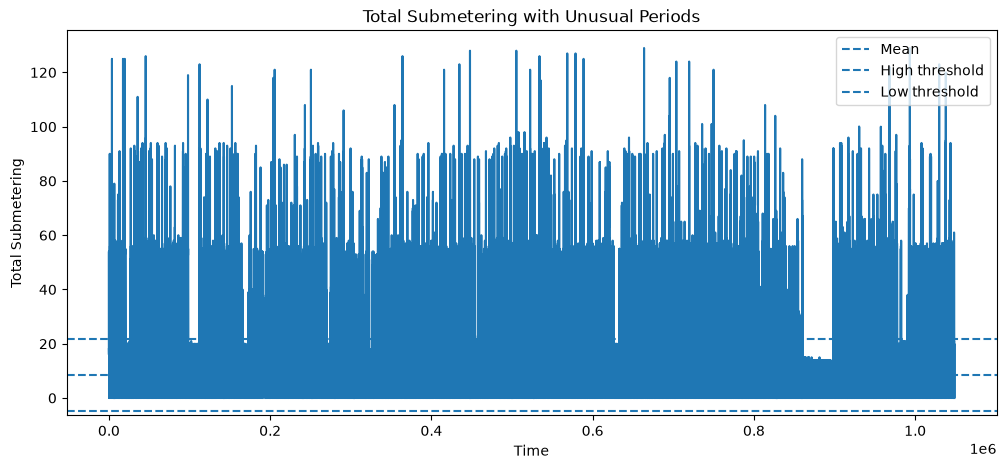

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Total_Submetering"])

plt.axhline(mean, linestyle="--", label="Mean")
plt.axhline(high, linestyle="--", label="High threshold")
plt.axhline(low, linestyle="--", label="Low threshold")

plt.xlabel("Time")
plt.ylabel("Total Submetering")
plt.title("Total Submetering with Unusual Periods")
plt.legend()

plt.show()

20. Which hour of the day has the highest Total_Submetering on average?

In [44]:
hourly_submetering = df.groupby("Hour")["Total_Submetering"].mean()

highest_hour = hourly_submetering.idxmax()
highest_value = hourly_submetering.max()

print("Hour with highest average Total_Submetering:", highest_hour)
print("Average Total_Submetering:", highest_value)

Hour with highest average Total_Submetering: 8
Average Total_Submetering: 14.408128061822948
